# 2D Mesh Cell-Size Sensitivity for Sediment Transport - Second Case: Weise Flume

**Model:** Weise 2D (`Weise_2D`, HEC's *2D Sediment Transport* example suite, plan *"Weise"*)

This is the **second case** for the 2D sediment mesh-sensitivity workflow. The primary case
(`examples/230_mesh_sensitivity_analysis.ipynb`) studied the **Chippewa River** reach (US Customary
units, ~200 ft cells). This notebook applies the *same* workflow and the *same* library reader
(`HdfResultsSediment`) to a deliberately contrasting model:

- **Controlled physical flume** (16.5 m x 1.0 m), **SI units (metres)**, base cell ~0.1 m.
- **Wu transport function**, 20 grain classes, 2D erosion enabled, **1-hour** event.

Running the identical analysis on a metric, sub-meter flume validates that the mesh-regeneration
workflow and the `HdfResultsSediment` reader are **unit-system agnostic**, and gives an independent
second data point on how mesh resolution shapes mobile-bed results.

> See notebook 230 for the full discussion of **mesh-regeneration limitations** (structures with
> connections on spacing-controlled breaklines failing when cell size changes). Like Chippewa, Weise
> is **structure-free and breakline-free**, so cell size is the only variable.

## Setup

In [1]:
USE_LOCAL_SOURCE = True

import sys
from pathlib import Path
if USE_LOCAL_SOURCE:
    local_path = str(Path.cwd().parent)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"LOCAL SOURCE MODE: {local_path}/ras_commander")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

from ras_commander import init_ras_project, RasExamples, RasPlan, RasCmdr
from ras_commander.geom.GeomMesh import GeomMesh
from ras_commander.hdf import HdfResultsPlan, HdfResultsSediment

import ras_commander
print(f"Loaded: {ras_commander.__file__}")

LOCAL SOURCE MODE: G:\GH\ras-commander/ras_commander


Loaded: G:\GH\ras-commander\ras_commander\__init__.py


## Parameters

In [2]:
PROJECT_NAME  = "Weise_2D"
RAS_VERSION   = "7.0"
TEMPLATE_PLAN = "01"           # "Weise" sediment plan (mobile bed, Wu transport)
MESH_NAME     = "2DArea"
SUFFIX        = "232_weise_meshsens"

# SI units (metres). As-built base spacing ~0.1 m (2,703 interior cells over a 16.5 x 1.0 m flume).
BASE_CELL_SIZE = 0.1           # m
# Fine (0.025 m) up to 2 x base (0.2 m).
CELL_SIZES = [0.2, 0.1, 0.05, 0.025]   # m (coarse -> fine)

# Mobile-bed runtime grows with cell count and Courant sub-stepping; the finest mesh
# (0.025 m, ~21k cells) projects to tens of minutes even over the 1-hour window, so it is gated.
# Raise this to execute the 0.025 m mesh.
EXECUTE_CELL_BUDGET = 8000     # cells

NUM_CORES = 2

print(f"Cell sizes (m): {CELL_SIZES}")
print(f"Execute cell budget: {EXECUTE_CELL_BUDGET:,} cells")

Cell sizes (m): [0.2, 0.1, 0.05, 0.025]
Execute cell budget: 8,000 cells


## Extract and Inspect

In [3]:
project_folder = RasExamples.extract_project(PROJECT_NAME, suffix=SUFFIX)
ras = init_ras_project(project_folder, RAS_VERSION)

print("Plans:")
print(ras.plan_df[['plan_number', 'Plan Title', 'Geom File', 'unsteady_number']].to_string(index=False))
template_geom = ras.plan_df.loc[ras.plan_df['plan_number'] == TEMPLATE_PLAN, 'Geom File'].values[0]
geom_path = Path(ras.geom_df.loc[ras.geom_df['geom_number'] == template_geom, 'full_path'].values[0])
gtxt = geom_path.read_text(errors='replace')
ptxt = (geom_path.parent / f"{ras.project_name}.p{TEMPLATE_PLAN}").read_text(errors='replace')

print(f"\nTemplate plan {TEMPLATE_PLAN} -> geometry g{template_geom}")
print("Run Sediment :", '-1 (ON)' if 'Run Sediment=-1' in ptxt else 'OFF')
print("2D areas     :", gtxt.count('Storage Area Is2D=-1'))
print("Sim window   :", [l.split('=')[1] for l in ptxt.splitlines() if l.startswith('Simulation Date=')])
print("Structures (Connection/Culvert/Gate):",
      gtxt.count('Connection='), gtxt.count('Culvert='), gtxt.count('Gate Name='))
print("Breaklines   :", len(GeomMesh.get_breakline_names(geom_path)))

2026-06-03 06:55:19 - ras_commander.RasExamples - INFO - Successfully extracted project 'Weise_2D' to G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens


2026-06-03 06:55:19 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-06-03 06:55:19 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-06-03 06:55:19 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


2026-06-03 06:55:19 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.3.1 at C:\Program Files (x86)\HEC\HEC-RAS\6.3.1\Ras.exe via filesystem (x86)


...

2026-06-03 06:55:19 - ras_commander.RasPrj - INFO - ras-commander v0.97.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-06-03 06:55:19 - ras_commander.RasPrj - INFO - Project initialized: Weise | Folder: G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens


2026-06-03 06:55:19 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe


2026-06-03 06:55:19 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://gpt-cmdr.github.io/ras-commander/
Repo: https://github.com/gpt-cmdr/ras-commander
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode()
  Plan Files:   RasPlan.clone_

Plans:
plan_number Plan Title Geom File unsteady_number
         01      Weise        08              01

Template plan 01 -> geometry g08
Run Sediment : -1 (ON)
2D areas     : 1
Sim window   : ['08Dec2016,0000,08Dec2016,0100']
Structures (Connection/Culvert/Gate): 0 0 0
Breaklines   : 0


## Regenerate Meshes Across Cell Sizes

Clone the geometry and regenerate the mesh at each cell size (0.025 m fine -> 0.2 m = 2x base).
No structures or breaklines, so regeneration is unconstrained.

In [4]:
mesh_rows = []
for cs in CELL_SIZES:
    new_geom = RasPlan.clone_geom(template_geom, ras_object=ras)
    gpath = Path(ras.geom_df.loc[ras.geom_df['geom_number'] == new_geom, 'full_path'].values[0])
    try:
        mr = GeomMesh.generate(geom_number=gpath, mesh_name=MESH_NAME, cell_size=cs,
                               max_iterations=8, ras_object=ras)
        status, gcells, gfaces = mr.status, mr.cell_count, mr.face_count
    except Exception as e:
        status, gcells, gfaces = f"ERROR: {e}", np.nan, np.nan
    will_run = np.isfinite(gcells) and gcells <= EXECUTE_CELL_BUDGET
    mesh_rows.append({"cell_size": cs, "geom": new_geom, "geom_path": gpath,
                      "gen_cells": gcells, "gen_faces": gfaces, "will_run": will_run})
    print(f"  {cs:>6.3f} m -> g{new_geom}  cells={gcells}  faces={gfaces}  "
          f"{'RUN' if will_run else 'gated'}")
mesh_df = pd.DataFrame(mesh_rows)

2026-06-03 06:55:19 - ras_commander.RasUtils - INFO - File cloned from G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.g08 to G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.g01


2026-06-03 06:55:19 - ras_commander.RasUtils - INFO - File cloned from G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.g08.hdf to G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.g01.hdf


2026-06-03 06:55:19 - ras_commander.RasUtils - INFO - Project file updated with new Geom entry: 01


2026-06-03 06:55:19 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.rasmap


2026-06-03 06:55:19 - ras_commander.RasPrj - WARNING - Could not resolve project CRS for G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens


...

2026-06-03 06:55:26 - ras_commander.geom.GeomMesh - INFO - Seeds via .NET RegenerateMeshPoints: 21643 (0 breaklines incl 0 struct, 1 perimeters)


2026-06-03 06:55:26 - ras_commander.geom.GeomMesh - INFO - [2DArea] 21643 seeds via .NET RegenerateMeshPoints


2026-06-03 06:55:27 - ras_commander.geom.GeomMesh - INFO - Text seeds patched → 21643 points in Weise.g04


2026-06-03 06:55:27 - ras_commander.geom.GeomMesh - INFO - [2DArea] Mesh complete: 21643 cells, 44002 faces in 1 iteration(s)


   0.025 m -> g04  cells=21643  faces=44002  gated


## Execute (constant native 1-hour window)

The plan's native simulation window (1 hour) is held constant across all meshes, so result
differences across meshes reflect cell-size resolution rather than changes in the flow forcing (numerical-scheme and time-step effects also vary with resolution). We also use
`RasPlan.set_sediment_output_variables()` to **request active-layer gradation output**
(`d50`/`d10`/`d90`) on each cloned plan -- the stock Weise plan omits it, so without this the
`Cell Active Layer Percentile Diameters` datasets would not be written.

In [5]:
def solver_solution(hdf_path):
    with h5py.File(hdf_path, 'r') as f:
        s = f.get('Results/Unsteady/Summary')
        return s.attrs.get('Solution', b'').decode() if s is not None else 'No Summary'

mesh_df['plan'] = None; mesh_df['hdf'] = None; mesh_df['solver'] = None; mesh_df['runtime_s'] = np.nan

for idx, row in mesh_df.iterrows():
    cs = row.cell_size
    if not row.will_run:
        mesh_df.at[idx, 'solver'] = 'GATED (not run)'
        print(f"  {cs:.3f} m: gated"); continue
    plan = RasPlan.clone_plan(TEMPLATE_PLAN, new_plan_shortid=f"m{str(cs).replace('.','p')}",
                              geometry=row.geom, ras_object=ras)
    # The stock Weise plan outputs at Sediment Output Level 3 and does NOT request
    # active-layer gradation. Enable it via the API so D50/D10/D90 are written.
    RasPlan.set_sediment_output_variables(
        plan, ["2D Cell d50 Active", "2D Cell d10 Active", "2D Cell d90 Active"],
        output_level=6, ras_object=ras)
    t0 = time.time()
    RasCmdr.compute_plan(plan, clear_geompre=True, num_cores=NUM_CORES, ras_object=ras)
    dt = time.time() - t0
    hdf = ras.plan_df.loc[ras.plan_df['plan_number'] == plan, 'HDF_Results_Path'].values[0]
    sol = solver_solution(hdf) if hdf and Path(hdf).exists() else 'No HDF'
    mesh_df.at[idx, 'plan'] = plan; mesh_df.at[idx, 'hdf'] = hdf
    mesh_df.at[idx, 'solver'] = sol; mesh_df.at[idx, 'runtime_s'] = dt
    print(f"  {cs:.3f} m: p{plan}  {sol}  ({dt:.0f}s)")

2026-06-03 06:55:27 - ras_commander.RasUtils - INFO - File cloned from G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.p01 to G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.p02


2026-06-03 06:55:27 - ras_commander.RasUtils - INFO - Successfully updated file: G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.p02


2026-06-03 06:55:27 - ras_commander.RasUtils - INFO - Project file updated with new Plan entry: 02


2026-06-03 06:55:27 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.rasmap


2026-06-03 06:55:27 - ras_commander.RasPrj - WARNING - Could not resolve project CRS for G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens


...

2026-06-03 06:58:18 - ras_commander.RasDialogWatchdog - INFO - DialogWatchdog started — polling every 1.5s for RAS dialog windows


2026-06-03 07:11:56 - ras_commander.RasCmdr - INFO - HEC-RAS execution completed for plan: 04


2026-06-03 07:11:56 - ras_commander.RasCmdr - INFO - Total run time for plan 04: 818.54 seconds


2026-06-03 07:11:56 - ras_commander.RasDialogWatchdog - INFO - DialogWatchdog stopped — no dialogs encountered


  0.050 m: p04  Unsteady Finished Successfully  (819s)
  0.025 m: gated


## Sediment Metrics vs. Cell Size

Same `HdfResultsSediment` reader as notebook 230. Because Weise is **SI**, the reader reports
`length_unit='m'` and native volumes in **m^3** (no acre-ft conversion). The stock Weise plan
outputs at `Sediment Output Level 3` and does **not** request active-layer gradation, so D50 would
be absent. We enabled it above with `RasPlan.set_sediment_output_variables(...)`, so `Mean D50`
populates here -- demonstrating both the reader and the plan-authoring helper.

In [6]:
records = []
for _, row in mesh_df.iterrows():
    rec = {"Cell Size (m)": row.cell_size,
           "Gen Cells": int(row.gen_cells) if np.isfinite(row.gen_cells) else None,
           "Solver": row.get('solver', 'GATED (not run)'),
           "Runtime (s)": round(row.runtime_s, 1) if pd.notna(row.get('runtime_s')) else None}
    hdf = row.get('hdf')
    if isinstance(hdf, str) and Path(hdf).exists() and "Finished Successfully" in str(row.get('solver', '')):
        vol = HdfResultsSediment.get_bed_change_volumes(hdf)
        if not vol.empty:
            v = vol.iloc[0]
            rec["Unit"]                  = v["length_unit"]
            rec["Cells (computed)"]      = int(v["n_cells"])
            rec["Net Bed Vol (m^3)"]     = round(v["net_bed_volume"], 4)
            rec["Erosion Vol (m^3)"]     = round(v["erosion_volume"], 4)
            rec["Deposition Vol (m^3)"]  = round(v["deposition_volume"], 4)
            rec["Max Scour (m)"]         = round(v["max_scour"], 4)
            rec["Max Deposition (m)"]    = round(v["max_deposition"], 4)
            # Active-layer gradation (D50) is only written when the plan requests it
            # as a sediment output variable. The Weise plan does not, so this is optional.
            try:
                d50 = HdfResultsSediment.get_active_layer_grain_class(hdf, "D50")
                wet = d50["surface_area"] > 0
                rec["Mean D50 (mm)"]     = round(float(d50.loc[wet, "d50_mm"].mean()), 3)
            except ValueError:
                rec["Mean D50 (mm)"]     = None
    records.append(rec)

summary_df = pd.DataFrame(records).sort_values("Cell Size (m)", ascending=False)
display(summary_df)
csv_path = Path(project_folder) / "weise_sediment_mesh_sensitivity_summary.csv"
summary_df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

2026-06-03 07:11:57 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.p02.hdf
2. No RASMapper projection file found
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:11:57 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.p02.hdf
2. No RASMapper projection file found
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:11:57 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.p03.hdf
2. No RASMapper projection file found
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:11:57 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.p03.hdf
2. No RASMapper projection file found
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:11:57 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.p04.hdf
2. No RASMapper projection file found
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:11:57 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.p04.hdf
2. No RASMapper projection file found
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


,Cell Size (m),Gen Cells,Solver,Runtime (s),Unit,Cells (computed),Net Bed Vol (m^3),Erosion Vol (m^3),Deposition Vol (m^3),Max Scour (m),Max Deposition (m),Mean D50 (mm)
0,0.200,320,Unsteady Finished Successfully,42.4,m,320.0,0.0014,-0.2661,0.2675,-0.1534,0.1743,5.279
1,0.100,1348,Unsteady Finished Successfully,127.3,m,1350.0,-0.0004,-0.2837,0.2833,-0.2064,0.2066,5.283
2,0.050,5406,Unsteady Finished Successfully,819.2,m,5406.0,-0.1001,-0.3206,0.2205,-0.2601,0.2174,5.264
3,0.025,21643,GATED (not run),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved: G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\weise_sediment_mesh_sensitivity_summary.csv


## Convergence and Spatial Bed Change

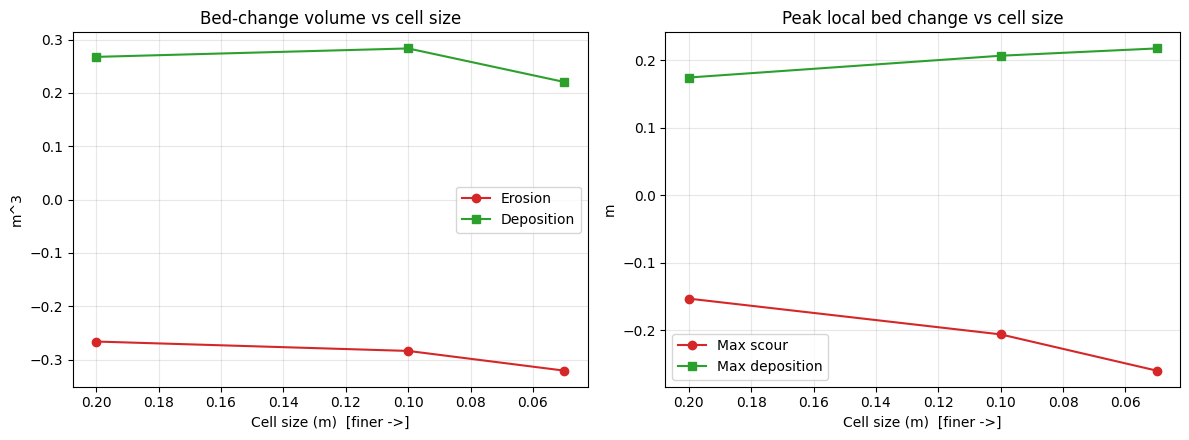

In [7]:
run = summary_df[summary_df["Solver"].astype(str).str.contains("Finished Successfully")].copy()
run = run.sort_values("Cell Size (m)")
if len(run) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot(run["Cell Size (m)"], run["Erosion Vol (m^3)"], 'o-', color="#d62728", label="Erosion")
    axes[0].plot(run["Cell Size (m)"], run["Deposition Vol (m^3)"], 's-', color="#2ca02c", label="Deposition")
    axes[0].set_title("Bed-change volume vs cell size"); axes[0].set_ylabel("m^3"); axes[0].legend()
    axes[1].plot(run["Cell Size (m)"], run["Max Scour (m)"], 'o-', color="#d62728", label="Max scour")
    axes[1].plot(run["Cell Size (m)"], run["Max Deposition (m)"], 's-', color="#2ca02c", label="Max deposition")
    axes[1].set_title("Peak local bed change vs cell size"); axes[1].set_ylabel("m"); axes[1].legend()
    for ax in axes:
        ax.invert_xaxis(); ax.set_xlabel("Cell size (m)  [finer ->]"); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("Need >=2 successful runs to plot convergence.")

2026-06-03 07:11:57 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.p02.hdf
2. No RASMapper projection file found
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


2026-06-03 07:11:57 - ras_commander.hdf.HdfBase - CRITICAL - No valid projection found. Checked:
1. HDF file projection attribute: G:\GH\ras-commander\examples\example_projects\Weise_2D_232_weise_meshsens\Weise.p04.hdf
2. No RASMapper projection file found
To fix this:
1. Open RASMapper
2. Click Map > Set Projection
3. Select an appropriate projection file or coordinate system
4. Save the RASMapper project


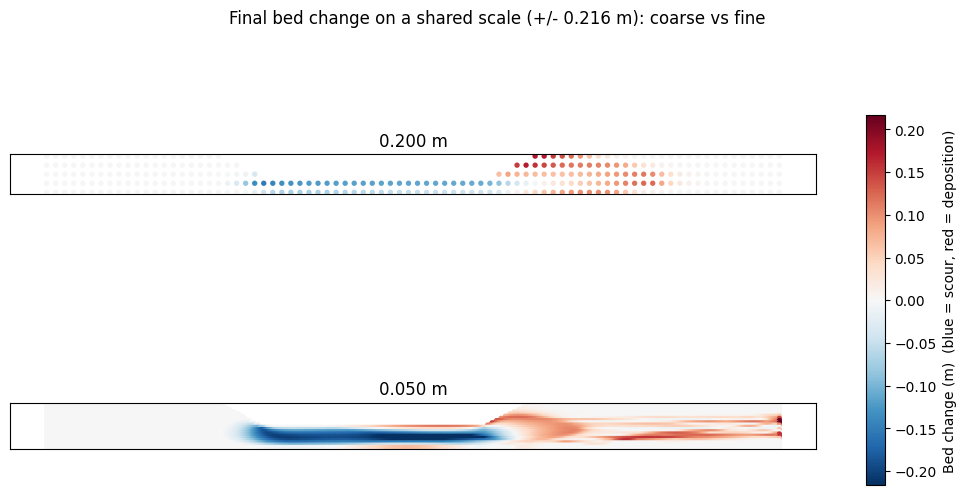

In [8]:
def bedchange_panel(ax, gdf, title, vmax):
    m = gdf["surface_area"] > 0
    sca = ax.scatter(gdf.geometry.x[m], gdf.geometry.y[m], c=gdf["bed_change"][m],
                     cmap="RdBu_r", vmin=-vmax, vmax=vmax, s=8)
    ax.set_title(title); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    return sca

ok = mesh_df[mesh_df['solver'].astype(str).str.contains("Finished Successfully", na=False)]
if len(ok) >= 2:
    crow, frow = ok.iloc[0], ok.iloc[-1]
    gdf_c = HdfResultsSediment.get_cell_bed_change(crow.hdf)
    gdf_f = HdfResultsSediment.get_cell_bed_change(frow.hdf)
    shared = max(np.nanpercentile(np.abs(g.loc[g["surface_area"] > 0, "bed_change"]), 98)
                 for g in (gdf_c, gdf_f)) or 0.01
    # flume is long and thin (16.5 x 1.0 m) -> stack panels vertically
    fig, axes = plt.subplots(2, 1, figsize=(13, 6))
    bedchange_panel(axes[0], gdf_c, f"{crow.cell_size:.3f} m", shared)
    sca = bedchange_panel(axes[1], gdf_f, f"{frow.cell_size:.3f} m", shared)
    fig.colorbar(sca, ax=axes, shrink=0.8,
                 label="Bed change (m)  (blue = scour, red = deposition)")
    fig.suptitle(f"Final bed change on a shared scale (+/- {shared:.3f} m): coarse vs fine")
    plt.show()
else:
    print("Need >=2 successful runs for spatial comparison.")

## Conclusion

Applying the notebook-230 workflow to the **Weise metric flume** validates that the approach and the
`HdfResultsSediment` reader are **unit-system agnostic**: the reader auto-detects SI and returns
native m^3 / m results. As with Chippewa, mesh refinement sharpens local scour/deposition while the
structure-free, breakline-free geometry lets mesh regeneration run cleanly across the full range.

Together, notebooks 230 (US Customary river reach) and 232 (SI flume) give two independent,
contrasting confirmations of the central point: **2D mesh cell size is a first-order control on
mobile-bed results**, not a neutral numerical knob.

> Analysis performed with [ras-commander](https://github.com/gpt-cmdr/ras-commander) by
> CLB Engineering Corporation.